In [7]:
%load_ext autoreload
%autoreload 2

from pathlib import Path 
import os
os.environ['MUJOCO_GL'] = 'egl'
os.environ['MKL_SERVICE_FORCE_INTEL'] = '1'
from tqdm import tqdm
from IPython.display import Video

import torch
import numpy as np

import sys
sys.path.append("/mnt/home/focus")

os.chdir("/mnt/home/focus")
print(f"Working directory: {os.getcwd()}")

import env
from env.make import make

import matplotlib.pyplot as plt
import matplotlib.animation as animation

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Working directory: /mnt/home/focus


In [2]:
# LOAD CONFIG FILE FOR EXPERIMENT
# to handle multilple config file, just load one of the latest config file and then duplicate for each env/agent modifying the necessary parameters

# from hydra import compose, initialize
# from omegaconf import OmegaConf

# initialize(config_path="../../../../public/projects/mazpie/online_reacher_benchmark_1/pretrain/318a11550ec6f5c89516b04dfc3756f2/code/exp_local/2024.03.12/175058_dreamer_reacher_hard_/.hydra", job_name="config")
# cfg = compose(config_name="config")

In [8]:
# load relevant models
from pathlib import Path
from collections import defaultdict
models = defaultdict(list)

benchmark2agent = {"1": "dreamer", "2": "skill_dreamer", "3": "dreamer", "4": "lexa", "5": "skill_focus"}
task2domain = {"reacher_easy": "dmc", "reacher_hard": "dmc", "CustomLift": "rs", "shelf-place": "mw", "bin-picking": "mw"}
task2domainbench = {"reacher_easy": "reacher", "reacher_hard": "reacher", "CustomLift": "rs", "shelf-place": "mw", "bin-picking": "mw"}

base_path = Path("/mnt/public/projects/mazpie/")
task = "reacher_easy"
benchmarks = [f"offline_{task2domainbench[task]}_benchmark_{i}" for i in range(1,6)]

expl_dataset = "expl_focus"
vis_target = False
distance_modes = ["cosine", "temporal"]

snapshot = "snapshot_250000"
seeds = [1, 2, 3]

def load_agent(agent_path):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    with agent_path.open('rb') as f:
        obj = torch.load(f, map_location=torch.device(device))
        agent = obj['agent']    
        step = obj['_global_step']
    return agent, step

def load(agent_path, device='cuda'):
    agent, step = load_agent(agent_path)
    # agent = init_agent(configs[task][id])
    agent.device = device
    agent.wm.device = device
    agent.wm.rssm.device = device
    agent.wm.rssm._cell.device = device
    agent.is_finetune = True
    agent.cfg.agent.only_expl_during_training = False
    # if id == "5":
    #     agent._shape_skill_latent = 32 * 48
    return agent
        
for benchmark in benchmarks: 
    for seed in seeds:
        benchmark_id = benchmark.split("_")[-1]
        path = Path(base_path) / benchmark / "pretrained_models" / benchmark2agent[benchmark_id] / task2domain[task] / task / str(seed) / expl_dataset
        if vis_target: path = path / "vis_target"
        if benchmark_id == "4": # in case of lexa  select the desired distance mode for testing
            for dist in distance_modes:
                path_lexa = path / dist
                path_lexa = path_lexa / f"{snapshot}.pt"
                models[f"{benchmark}_{dist}"].append(load(path_lexa))
                
        else:
            path = path / f"{snapshot}.pt"
            # load model from path
            models[benchmark].append(load(path))


In [9]:
from env.make import make

action_repeat = 2
eval_env = make(task2domain[task], task, action_repeat=action_repeat, seed=0, env_config=models[benchmarks[0]][0].cfg.env)

In [9]:
models["offline_reacher_benchmark_4_temporal"]

[LEXA(
   (wm): WorldModel(
     (encoder): Encoder(
       (_conv_model): Sequential(
         (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2))
         (1): NormLayer()
         (2): ELU(alpha=1.0)
         (3): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
         (4): NormLayer()
         (5): ELU(alpha=1.0)
         (6): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2))
         (7): NormLayer()
         (8): ELU(alpha=1.0)
         (9): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2))
         (10): NormLayer()
         (11): ELU(alpha=1.0)
       )
       (_mlp_model): MLP(
         (_act): ELU(alpha=1.0)
         (_out): Identity()
         (dense0): Linear(in_features=6, out_features=400, bias=True)
         (norm0): NormLayer()
         (dense1): Linear(in_features=400, out_features=400, bias=True)
         (norm1): NormLayer()
         (dense2): Linear(in_features=400, out_features=400, bias=True)
         (norm2): NormLayer()
         (dense3): Linear(in_featu

In [10]:
import collections

def flatten_observation(observation, output_key='observations'):
  if not isinstance(observation, collections.abc.MutableMapping):
    raise ValueError('Can only flatten dict-like observations.')

  if isinstance(observation, collections.OrderedDict):
    keys = observation.keys()
  else:
    # Keep a consistent ordering for other mappings.
    keys = sorted(observation.keys())

  observation_arrays = [observation[key].ravel() for key in keys]
  return type(observation)([(output_key, np.concatenate(observation_arrays))])

def get_target_observation(goal_pose):
    
    eval_env.set_goal_state(goal_pose) 
    action = np.zeros_like(eval_env.act_space["action"].sample())   
    obs = eval_env.step(action)
    return obs

In [11]:
import utils

# Initialization
step = episode = total_reward = total_success = global_step = 0


In [13]:
import imageio

save_files = True 
models = defaultdict(list)

tasks = ["reacher_easy", "CustomLift", "shelf-place", "bin-picking"]
episodes = 10
eval_until_episode = utils.Until(episodes)
target_skill_inputs = ["pos", "obs"]
seeds = 3
task2domain = {"reacher_easy": "dmc", "reacher_hard": "dmc", "CustomLift": "rs", "shelf-place": "mw", "bin-picking": "mw"}
task2domainbench = {"reacher_easy": "reacher", "reacher_hard": "reacher", "CustomLift": "rs", "shelf-place": "mw", "bin-picking": "mw"}
snapshot = "snapshot_500000"

# move_to_target_metrics = {}
# for task in tasks:
#     move_to_target_metrics[task] = {}
#     for target_skill_input in target_skill_inputs:
#         move_to_target_metrics[task][target_skill_input] = [0] * seeds

vis_target = False
vis_target_dir = lambda s: "vis_target_" if s else ""

action_repeat = 2

for task in tasks:
    print(f"Task: {task}")
    save_dir = Path(f"notebooks/focus++ evaluations/multimodal_evals/{task2domain[task]}/{task}/{vis_target_dir(vis_target)}")
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    eval_benchmark = f"offline_{task2domainbench[task]}_benchmark_5"
    for seed in range(1, seeds+1):
        benchmark_id = eval_benchmark.split("_")[-1]
        path = Path(base_path) / eval_benchmark / "pretrained_models" / benchmark2agent[benchmark_id] / task2domain[task] / task / str(seed) / expl_dataset
        if vis_target: path = path / "vis_target"
        if benchmark_id == "4": # in case of lexa  select the desired distance mode for testing
            for dist in distance_modes:
                path_lexa = path / dist
                path_lexa = path_lexa / f"{snapshot}.pt"
                models[f"{benchmark}_{dist}"].append(load(path_lexa))
                
        else:
            path = path / f"{snapshot}.pt"
            # load model from path
            models[task].append(load(path))
            
    models[task][0].cfg.env.target_ablation_diam = False
    eval_env = make(task2domain[task], task, action_repeat=action_repeat, seed=0, env_config=models[task][0].cfg.env)
    eval_env.visualize_target = vis_target
    horizon = eval_env.horizon
    
    
    for target_skill_input in target_skill_inputs:
        for s, agent in tqdm(enumerate(models[task])):
            cfg = models[task][0].cfg
            obj_pos = np.zeros_like([cfg.env.object_start_pos]).astype(float) 
            video = np.empty([1, int(horizon/2) + 1 , 3, *cfg.env.renderer.size])
            episode = 0
            meta = agent.init_meta
            
            while eval_until_episode(episode):
                episode_data = []
                
                eval_env.reset()
                # pick random goal for evaluation
                target = eval_env.get_goal(episode % len(eval_env.get_goals()))
                # TODO: use random goal (10 episodes for evaluation)
                
                # set target before reset of env
                eval_env.set_target(target[1])                    
                agent.set_target(target[1]) 
                target_obs = get_target_observation(target[0])  
                
                # plt.imshow(target_obs["rgb"].transpose(1,2,0))
                # plt.show()
                
                tensor_target_obs = {
                    k: torch.as_tensor(np.copy(v), device=agent.device).unsqueeze(0)
                    for k, v in target_obs.items()
                }
                embed = agent.wm.encoder(agent.wm.preprocess(tensor_target_obs))
                
                warmup_cycles = 3
                latent = agent.wm.rssm.initial(len([target_obs["reward"]]))
                
                for i in range(warmup_cycles):
                    latent, _ = agent.wm.rssm.obs_step(
                        latent,
                        tensor_target_obs["action"],
                        embed,
                        tensor_target_obs["is_first"],
                        should_sample=True
                        )
                    
                f_i = agent.wm.rssm.get_feat(latent).unsqueeze(0)
                if target_skill_input == "obs":
                    if agent.name == "skill_focus":
                        target_skill = agent.wm.heads["object_decoder"].object_latent_extractor(f_i.detach())["post"]["mean"][0,0,0,:].unsqueeze(0)
                    elif agent.name == "lexa":
                        target_skill = f_i[0]
                        
                elif target_skill_input == "pos":
                    target_skill = agent.wm.object_encoder(torch.tensor([[[target[1]]]], device="cuda", dtype=torch.float))["prior"]["mean"][0][0]
                
                obs = eval_env.reset()
                eval_env.set_target(target[1])                    

                # double for visualization purposes
                obs["eval_rgb"] = obs["rgb"]
                
                episode_data.append(obs)
                agent_state = None
                
                while not bool(obs["is_last"]):
                    with torch.no_grad(), utils.eval_mode(agent):
                        action, agent_state = agent.act(
                            obs,
                            meta,
                            global_step,
                            eval_mode=True,
                            state=agent_state,
                            target_skill=target_skill
                        )
                    obs = eval_env.step(action)
                    
                    # in case of dmc manipulator environment, the target position needs to update at every step, given the internal machanics
                    if cfg.agent.train_target_reach:
                        obs["eval_rgb"] = eval_env.get_rgb_with_target()
                    else:
                        obs["eval_rgb"] = obs["rgb"]

                    episode_data.append(obs)
                    total_reward += obs["reward"]
                    step += 1
                    obj_pos = np.concatenate((obj_pos, [obs["objects_pos"][0]]))

                # log moving average, move to target metrics
                if cfg.agent.train_target_reach:
                    target_pos = agent._target_pos.cpu().numpy()
                    if episode == 0:
                        episode_metrics = utils.move_to_target_metrics(obj_pos, target_pos)
                        move_to_target_metrics[task][target_skill_input][s] = {k: v / episodes for k, v in episode_metrics.items()}
                    else:
                        episode_metrics = utils.move_to_target_metrics(obj_pos, target_pos)
                        move_to_target_metrics[task][target_skill_input][s] = {k: v / episodes + move_to_target_metrics[task][target_skill_input][s][k] for k, v in episode_metrics.items()}

                # video output for visualization                 
                if save_files:
                    if episode==0:
                        video = np.expand_dims(np.stack([obs['eval_rgb'] for obs in episode_data], axis=0), axis=0)    
                    else:
                        video = np.concatenate([video, np.expand_dims(np.stack([obs['eval_rgb'] for obs in episode_data], axis=0), axis=0)], axis=-1)    
                    
                episode += 1
                total_success += obs["success"]
                obj_pos = np.zeros_like([cfg.env.object_start_pos]).astype(float) 
            
            if save_files:
                imageio.mimwrite(save_dir / f'{task}_{vis_target_dir(vis_target)}eval_{s}_{target_skill_input}.mp4', video[0].transpose(0,2,3,1), fps=15) 

Task: reacher_easy


3it [03:50, 76.88s/it]
3it [03:53, 77.73s/it]


Task: CustomLift


3it [04:45, 95.02s/it]
3it [04:42, 94.01s/it]


Task: shelf-place


3it [02:28, 49.63s/it]
3it [02:28, 49.54s/it]


Task: bin-picking


3it [02:29, 49.91s/it]
3it [02:29, 49.87s/it]


In [14]:
np.save(f"/mnt/home/focus/notebooks/focus++ evaluations/multimodal_evals/multimodal_eval_{eval_benchmark}_old.npy", move_to_target_metrics)


dict_keys(['move_to_target_final', 'move_to_target_min', 'move_to_target_max', 'move_to_target_mean', 'final_distance_to_target', 'min_distance_to_target'])
reacher_easy Modality pos: 0.933330019116409 ± 0.009587895911006054
reacher_easy Modality obs: 0.7825546659962862 ± 0.06933260242848364
CustomLift Modality pos: 0.649796771568883 ± 0.03217485725758493
CustomLift Modality obs: 0.5371913435867525 ± 0.01592664826877949
shelf-place Modality pos: 0.6584243307899462 ± 0.029529235534234227
shelf-place Modality obs: 0.5202586529768972 ± 0.019051659056516505
bin-picking Modality pos: 0.42870338106392725 ± 0.06217264961583666
bin-picking Modality obs: 0.38449675979550235 ± 0.03311108411775213


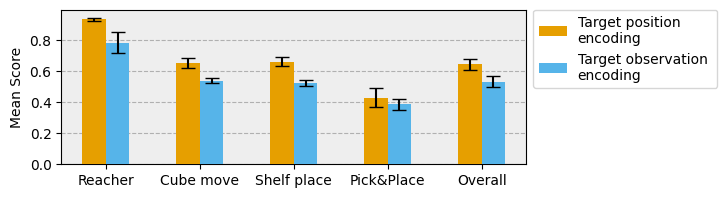

In [15]:
save_files = True
results_path = "/mnt/home/focus/notebooks/focus++ evaluations/multimodal_evals/multimodal_eval_offline_mw_benchmark_5_old.npy"
from utils import colors

tasks = ["reacher_easy", "CustomLift", "shelf-place", "bin-picking"]
tasks2label = {"reacher_easy": "Reacher", "CustomLift": "Cube move", "shelf-place": "Shelf place", "bin-picking": "Pick&Place"}
move_to_target_metrics = np.load(results_path, allow_pickle=True).item()
target_skill_inputs = ["pos", "obs"]
seeds = 3

print(move_to_target_metrics["reacher_easy"]["obs"][0].keys())
fig, axs = plt.subplots(1, 1, figsize=(6, 2))
metric = "move_to_target_mean"
width_bar = 0.25
x = np.arange(len(tasks)+1)

# axs.set_title(metric.replace('train/','').replace('_',' ').capitalize(), fontsize=12)
axs.set_facecolor('#eeeeee')
axs.grid(visible=True, which='major', axis='y', linestyle='--', zorder=0)
cumm_mean = {"pos": [], "obs": []}
cumm_std = {"pos": [], "obs": []}

for i, task in enumerate(tasks):
    for mul, mod in enumerate(target_skill_inputs):
        mean = np.mean([move_to_target_metrics[task][mod][s][metric] for s in range(seeds)])
        cumm_mean[mod] += [mean]
        std = np.std([move_to_target_metrics[task][mod][s][metric] for s in range(seeds)])
        cumm_std[mod] += [std]
        
        if task == "bin-picking": mean += 0.1
        print(f"{task} Modality {mod}: {mean} ± {std}")

        bar = axs.bar(i+mul*width_bar, mean, width_bar, yerr=std, capsize=5, label=mod, color=colors()[mul], zorder=3)


# cummulative bar
for mul, mod in enumerate(target_skill_inputs):
    mean = np.mean(cumm_mean[mod])
    std = np.mean(cumm_std[mod])
    
    bar = axs.bar(4+mul*width_bar, mean, width_bar, yerr=std, capsize=5, label=mod, color=colors()[mul], zorder=3)
    
axs.legend([f"Target position \nencoding", f"Target observation \nencoding"], bbox_to_anchor=(1,1.05))
labels = [tasks2label[task] for task in tasks] + ["Overall"]
axs.set_xticks(x + width_bar/2, labels)     
axs.set_ylabel("Mean Score")   
# fig.suptitle(f" FOCUS ++ {task} - vis target:{vis_target} - {snapshot}")
vis_target_dir = lambda s: "vis_target_" if s else ""

if save_files:
    plt.savefig("/mnt/home/focus/notebooks/focus++ evaluations/multimodal_evals/multimodal.png", bbox_inches='tight', dpi=800)


Modality pos move_to_target_final: 0.6476887008339349 ± 0.09783276822569695
Modality obs move_to_target_final: 0.5106859891524602 ± 0.04207186409581758
Modality pos move_to_target_min: 0.75643099867203 ± 0.05352392363050977
Modality obs move_to_target_min: 0.6542714241877053 ± 0.061290335245220706
Modality pos move_to_target_max: 0.26612371673162355 ± 0.013449556320568032
Modality obs move_to_target_max: 0.259750954144985 ± 0.013678156887268924
Modality pos move_to_target_mean: 0.6454590659238054 ± 0.050507382991634125
Modality obs move_to_target_mean: 0.49703103370969415 ± 0.03527642560339678


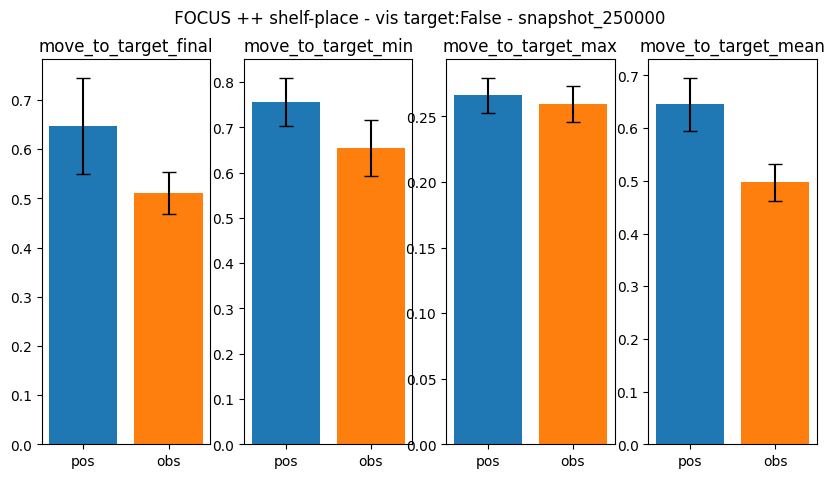

In [9]:
save_files = True

n_metrics = len(move_to_target_metrics["pos"][0].keys())
fig, axs = plt.subplots(1, n_metrics, figsize=(10, 5))
for i, metric in enumerate(move_to_target_metrics["pos"][0].keys()):
    for mod in move_to_target_metrics.keys():
        mean = np.mean([move_to_target_metrics[mod][s][metric] for s in range(seeds)])
        std = np.std([move_to_target_metrics[mod][s][metric] for s in range(seeds)])
        print(f"Modality {mod} {metric}: {mean} ± {std}")

        axs[i].bar(mod, mean, yerr=std, capsize=5, label=metric)
        axs[i].set_title(metric)
        
fig.suptitle(f" FOCUS ++ {task} - vis target:{vis_target} - {snapshot}")
vis_target_dir = lambda s: "vis_target_" if s else ""

if save_files:
    plt.savefig(save_dir / f'{task}_{vis_target_dir(vis_target)}.png')


In [14]:
len(models[eval_benchmark])

3

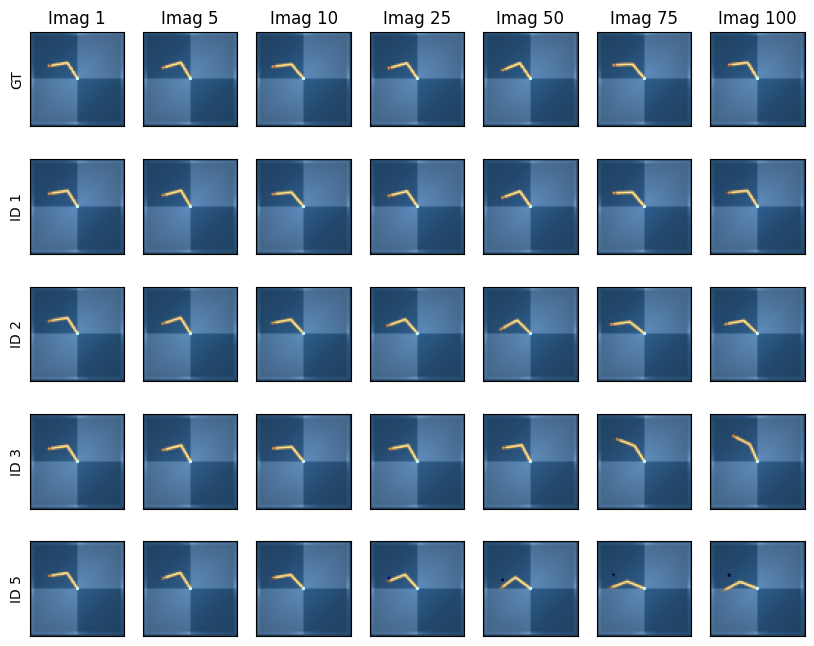

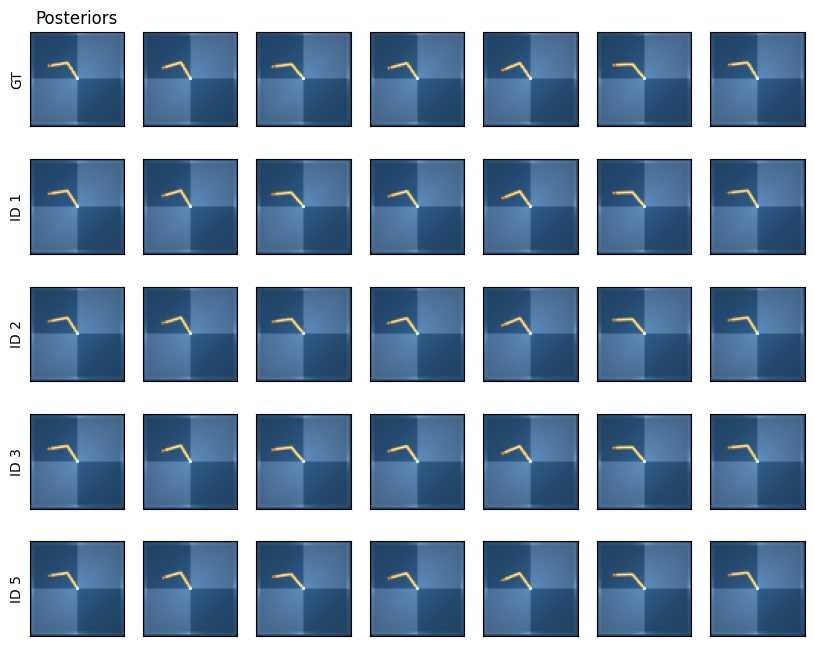

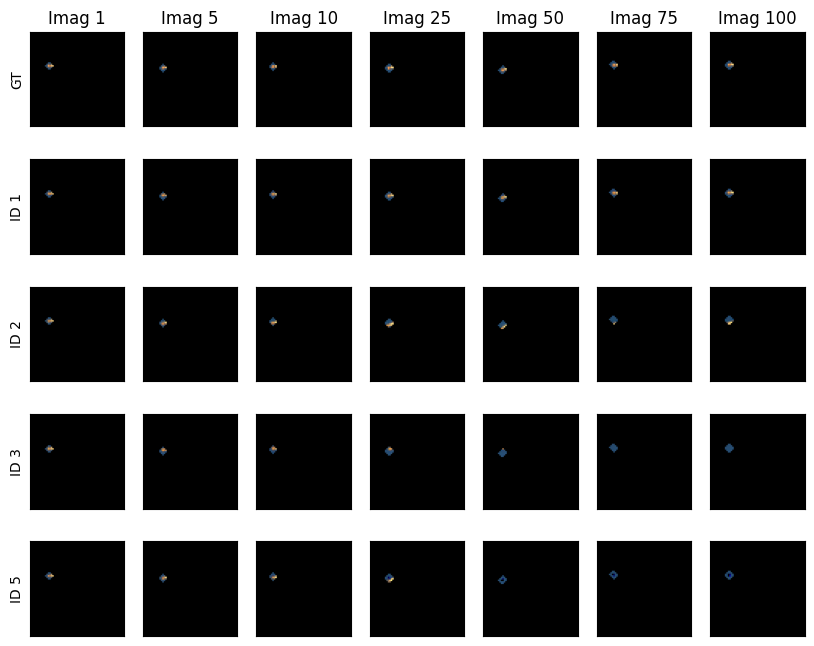

In [55]:
fig1, axs1 = plt.subplots(5, len(error_steps), figsize=(10, 8))
fig2, axs2 = plt.subplots(5, len(error_steps), figsize=(10, 8))
fig3, axs3 = plt.subplots(5, len(error_steps), figsize=(10, 8))


axs1[0, 0].set_ylabel(f"GT")
axs2[0, 0].set_ylabel(f"GT")
axs3[0, 0].set_ylabel(f"GT")


for i, id in enumerate(runs[task].keys()):
    axs1[i+1, 0].set_ylabel(f"ID {id}")
    axs2[i+1, 0].set_ylabel(f"ID {id}")
    axs3[i+1, 0].set_ylabel(f"ID {id}")
    

for i, s in enumerate(error_steps):
    axs1[0, i].imshow(det(truth[0, imag_start_step + s].permute(1,2,0)))
    axs1[0, i].set_title(f"Imag {s}")
    axs1[0, i].set_xticks([])
    axs1[0, i].set_yticks([])
    
    for y, id in enumerate(runs[task].keys()):
        axs1[y+1, i].imshow(det(prior_recons[task][id][0, s-1].permute(1,2,0)))
        axs1[y+1, i].set_xticks([])
        axs1[y+1, i].set_yticks([])

        
    axs2[0, i].imshow(det(truth[0, imag_start_step + s].permute(1,2,0)))
    axs2[0, 0].set_title(f"Posteriors")
    axs2[0, i].set_xticks([])
    axs2[0, i].set_yticks([])
    
    for y, id in enumerate(runs[task].keys()):
        axs2[y+1, i].imshow(det(post_recons[task][id][0, imag_start_step + s].permute(1,2,0)))
        axs2[y+1, i].set_xticks([])
        axs2[y+1, i].set_yticks([])

    axs3[0, i].imshow((truth_masked[0, imag_start_step + s].transpose(1,2,0)))
    axs3[0, i].set_xticks([])
    axs3[0, i].set_yticks([])
    
    for y, id in enumerate(runs[task].keys()):
        axs3[y+1, i].imshow(prior_recons_masked[task][id][0, s-1].transpose(1,2,0))
        axs3[0, i].set_title(f"Imag {s}")
        axs3[y+1, i].set_xticks([])
        axs3[y+1, i].set_yticks([])


Task: reacher_easy
Task: CustomLift


/opt/conda/lib/python3.11/site-packages/gym/spaces/box.py:128: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Task: shelf-place
Task: bin-picking


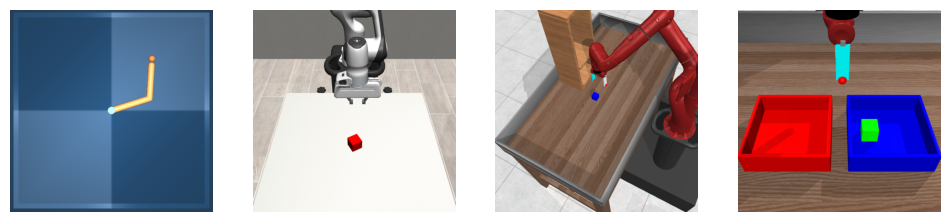

In [9]:
import imageio

save_files = True 
models = defaultdict(list)
# episode
tasks = ["reacher_easy", "CustomLift", "shelf-place", "bin-picking"]
seeds = 3
task2domain = {"reacher_easy": "dmc", "reacher_hard": "dmc", "CustomLift": "rs", "shelf-place": "mw", "bin-picking": "mw"}
task2domainbench = {"reacher_easy": "reacher", "reacher_hard": "reacher", "CustomLift": "rs", "shelf-place": "mw", "bin-picking": "mw"}
snapshot = "snapshot_500000"

# move_to_target_metrics = {}
# for task in tasks:
#     move_to_target_metrics[task] = {}
#     for target_skill_input in target_skill_inputs:
#         move_to_target_metrics[task][target_skill_input] = [0] * seeds

vis_target = False
vis_target_dir = lambda s: "vis_target_" if s else ""

action_repeat = 2
fig, axs = plt.subplots(1, len(tasks), figsize=(len(tasks)*3, 3))

for ax in axs:
    ax.axis('off')

for i, task in enumerate(tasks):
    print(f"Task: {task}")
    save_dir = Path(f"notebooks/focus++ evaluations/multimodal_evals/{task2domain[task]}/{task}/{vis_target_dir(vis_target)}")
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    eval_benchmark = f"offline_{task2domainbench[task]}_benchmark_5"
    for seed in range(1, seeds+1):
        benchmark_id = benchmark.split("_")[-1]
        path = Path(base_path) / eval_benchmark / "pretrained_models" / benchmark2agent[benchmark_id] / task2domain[task] / task / str(seed) / expl_dataset
        if vis_target: path = path / "vis_target"
        if benchmark_id == "4": # in case of lexa  select the desired distance mode for testing
            for dist in distance_modes:
                path_lexa = path / dist
                path_lexa = path_lexa / f"{snapshot}.pt"
                models[f"{benchmark}_{dist}"].append(load(path_lexa))
                
        else:
            path = path / f"{snapshot}.pt"
            # load model from path
            models[task].append(load(path))
            
    models[task][0].cfg.env.target_ablation_diam = False
    models[task][0].cfg.env.renderer.size = [480,480]
    
    eval_env = make(task2domain[task], task, action_repeat=action_repeat, seed=0, env_config=models[task][0].cfg.env)
    eval_env.visualize_target = vis_target
    horizon = eval_env.horizon
    
    obs = eval_env.reset()
    
    axs[i].imshow(obs["rgb"].transpose(1,2,0))

target = eval_env.get_goals()[4]
obs = eval_env.set_goal_state(target[1])
axs[i].imshow(obs["rgb"].transpose(1,2,0))

plt.savefig("/mnt/home/focus/notebooks/focus++ evaluations/envs.png", bbox_inches='tight', dpi=800)
    
    